In [12]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from src.data_preprocessing import cargar_y_preprocesar_datos


In [13]:
# 1. Configuración visual
plt.style.use("ggplot")
sns.set(font_scale=1.1)

In [14]:
# 2. Cargar los datos y el modelo entrenado
ruta_csv = '../data/raw/StudentPerformanceFactors.csv'
df = cargar_y_preprocesar_datos(ruta_csv, normalizar=True)

In [15]:
# 3. Separar en variables de entrada (X) y salida (y)
X = df.drop(columns='calificacion_examen')
y_real = df['calificacion_examen']

In [16]:
# 4. Cargar el modelo entrenado
modelo_rf = joblib.load('../models/trained/modelo_random_forest.pkl')


In [17]:
# 5. Realizar las predicciones
y_pred = modelo_rf.predict(X)

In [18]:
# 6. Calcular las métricas de evaluación
mae = mean_absolute_error(y_real, y_pred)
mse = mean_squared_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)

# Mostrar las métricas
print(f"📊 Evaluación del modelo sobre todo el dataset:")
print(f"MAE: {mae:.2f} (error promedio de {mae:.2f} puntos sobre 20)")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f} (explica el {r2 * 100:.0f}% de la varianza en las calificaciones)")


📊 Evaluación del modelo sobre todo el dataset:
MAE: 0.13 (error promedio de 0.13 puntos sobre 20)
MSE: 0.03
R²: 0.92 (explica el 92% de la varianza en las calificaciones)


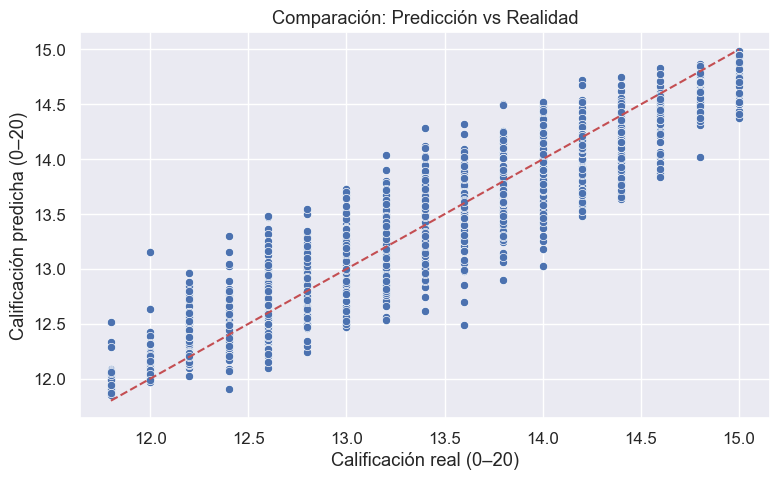

In [19]:
# 7. Gráfico de Predicción vs Realidad
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_real, y=y_pred)
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 'r--')
plt.xlabel("Calificación real (0–20)")
plt.ylabel("Calificación predicha (0–20)")
plt.title("Comparación: Predicción vs Realidad")
plt.tight_layout()
plt.show()

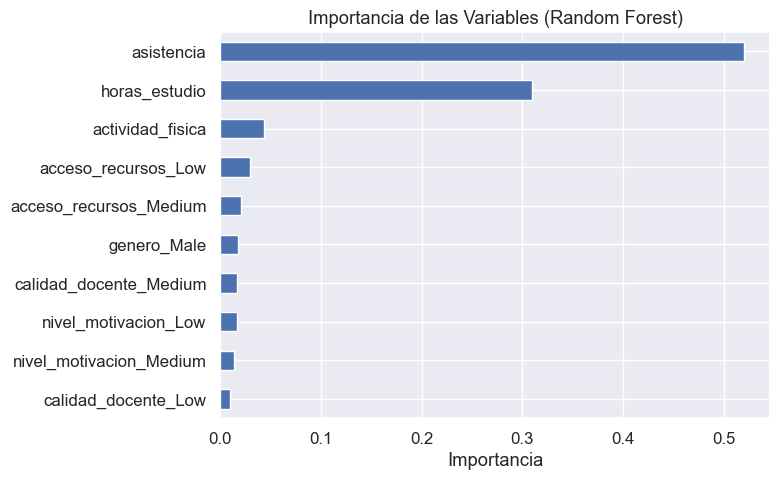

In [20]:
# 8. Gráfico de Importancia de las Variables
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias.sort_values(ascending=True).plot(kind='barh', figsize=(8, 5))
plt.title("Importancia de las Variables (Random Forest)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [21]:
# 9. Evaluación de los errores (Top 10 mayores errores)
df_resultados = pd.DataFrame({
    'real': y_real,
    'predicho': y_pred
})
df_resultados['error_absoluto'] = abs(df_resultados['real'] - df_resultados['predicho'])

# Ordenar por error
df_top_errores = df_resultados.sort_values(by='error_absoluto', ascending=False).head(10)

# Mostrar los 10 casos con mayor error
print("🔍 Top 10 errores más altos:")
df_top_errores

🔍 Top 10 errores más altos:


,real,predicho,error_absoluto
2211,12.0,13.159333,1.159333
544,13.6,12.494000,1.106000
2853,14.0,13.026000,0.974000
4444,13.6,12.696000,0.904000
2944,12.4,13.303200,0.903200
1122,13.8,12.898333,0.901667
1094,13.4,14.284629,0.884629
4905,12.6,13.480000,0.880000
715,12.6,13.476000,0.876000
6323,13.2,14.037000,0.837000


In [22]:
# Crear DataFrame con los resultados (predicciones vs reales)
df_resultados = pd.DataFrame({
    'calificacion_real': y_real,
    'calificacion_predicha': y_pred,
    'error_absoluto': abs(y_real - y_pred),
    'origen': 'Evaluación'  # Indica que proviene del notebook de evaluación
})

# Guardar el DataFrame como CSV con nombre único
df_resultados.to_csv('../data/processed/resultados_evaluacion_modelo.csv', mode='a', header=False, index=False)

# Imprimir las primeras filas para verificar
df_resultados.head()


,calificacion_real,calificacion_predicha,error_absoluto,origen
0,13.4,13.566,0.166,Evaluación
1,12.2,12.355,0.155,Evaluación
2,14.8,14.660,0.140,Evaluación
3,14.2,14.260,0.060,Evaluación
4,14.0,14.016,0.016,Evaluación
